
# ACECQA Education & Care Services — Full Analysis (Quality, Accessibility, Operations)

**Business context:** I work for government to improve education and care services across Australia. This notebook analyses the national register of approved education and care services (17,663 rows, NQA ITS extract) enriched with spatial/transport-access fields, across three streams:

**1. Service Quality** — how NQS ratings vary by state and service type, which Quality Area drags scores down, and whether transport proximity predicts quality.

**2. Accessibility & Coverage** — how much worse transport access is for rural services, whether urban/rural tracks with quality, and where families are most underserved.

**3. Operational Trends** — capacity and opening-hours patterns by service type, sector growth over time, and whether operational factors (or transport access) relate to quality.

Run the cells top to bottom. In Colab, the first code cell clones the source repo (raw data, a basemap file, and the ABS boundary shapefile used for the urban/rural classification) and installs dependencies.

**Design note:** every chart's headline stats are written into a running `summary` dict *immediately* after that chart is drawn, not recomputed later from leftover variables — this avoids a class of bug where a later cell's reused variable name (e.g. `worst`) silently overwrites an earlier cell's value before the final summary is written.


In [1]:

# --- Setup: run this first in Google Colab ---
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and not os.path.exists("Mart"):
    !git clone -b claude/acecqa-services-analysis-olfr4o https://github.com/martvanhoorn2003-svg/Mart.git
    %cd Mart
    !pip install -q geopandas scipy pyarrow

if os.path.basename(os.getcwd()) != "Mart" and os.path.isdir("Mart"):
    os.chdir("Mart")

print("Working directory:", os.getcwd())
print("Data file present:", os.path.exists("data/education_services.csv"))
print("SOS shapefile present:", os.path.exists("data/external/sos_2021/SOS_2021_AUST_GDA2020.shp"))


Working directory: /home/user/Mart
Data file present: True
SOS shapefile present: True


In [2]:

import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from scipy.spatial import cKDTree
import geopandas as gpd

RAW_PATH = Path("data/education_services.csv")
AU_STATES_GEOJSON = Path("data/external/au_states.geojson")
SOS_SHAPEFILE = Path("data/external/sos_2021/SOS_2021_AUST_GDA2020.shp")
FIG_DIR = Path("outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
summary = {}  # every chart appends its own headline stats here, right after drawing



## 1. Load the raw data and look for problems before trusting it

Before any analysis, check what's actually in the file — missing values, duplicate/implausible coordinates, and category values that don't match what the data dictionary implies.


In [3]:

raw = pd.read_csv(RAW_PATH, low_memory=False)
print(raw.shape)
raw[["ServiceName", "State", "Suburb", "Postcode", "geometry"]].head()


(17663, 103)


,ServiceName,State,Suburb,Postcode,geometry
0,Community Kids Waterford Early Education Centre,QLD,WATERFORD WEST,4133.0,"c(153.133902919075, -27.690513207433)"
1,KIDVENTURE EARLY LEARNING EAGLEBY,QLD,EAGLEBY,4207.0,"c(153.211787647201, -27.707467576353)"
2,Community Kids - Broadbeach Waters,QLD,BROADBEACH WATERS,4217.0,"c(153.410339594544, -28.024767831911)"
3,Little Scholars School of Early Learning Burle...,QLD,BURLEIGH WATERS,4220.0,"c(153.431380518447, -28.082157591396)"
4,Small World Child Care Centre,QLD,CARRARA,4211.0,"c(153.351670127991, -28.005580607804)"


In [4]:

dup_geom = raw["geometry"].value_counts()
dup_geom = dup_geom[dup_geom > 3]
print(dup_geom)


geometry
c(97.48747, 23.14958)                    10
c(145.741929531156, -17.007042588225)     4
c(145.363114748785, -38.083890922407)     4
c(151.128664850783, -33.878545511457)     4
c(149.1025717692, -35.307236507212)       4
Name: count, dtype: int64



**Finding:** `c(97.48747, 23.14958)` is shared by 10 services — and that coordinate is in Myanmar, not Australia.


In [5]:

bad = raw[raw["geometry"] == "c(97.48747, 23.14958)"]
bad[["ServiceName", "State", "Suburb", "Postcode", "FullAddress"]]


,ServiceName,State,Suburb,Postcode,FullAddress
1590,Ace Academy Morayfield,NaN,NaN,NaN,"NA, NA, NA, NA"
5385,Callala Bay Preschool Education Centre,NaN,NaN,NaN,"NA, NA, NA, NA"
6370,Koolyangarra Aboriginal Preschool Corporation,NaN,NaN,NaN,"NA, NA, NA, NA"
6731,Merriwa Pre-School And Activity Centre Incorpo...,NaN,NaN,NaN,"NA, NA, NA, NA"
7266,Guardian Childcare & Education Margaret Street,NaN,NaN,NaN,"NA, NA, NA, NA"
12140,Clarence City Council - Lindisfarne North OSHC,NaN,NaN,NaN,"NA, NA, NA, NA"
12909,Blossoms Childcare & Early Learning Centre,NaN,NaN,NaN,"NA, NA, NA, NA"
12977,Genius Childcare Lane Cove,NaN,NaN,NaN,"NA, NA, NA, NA"
16713,Clarke Creek State School Kindergarten,NaN,NaN,NaN,"NA, NA, NA, NA"
16834,Grow Early Education Maroochydore,NaN,NaN,NaN,"NA, NA, NA, NA"



Every one of these 10 rows has **no State, Suburb, Postcode or address at all** — the location-enrichment step fell back to the same placeholder point when it had nothing to geocode. These rows are **dropped** rather than imputed: there's no address information to recover. (All other duplicate-coordinate cases were checked too — e.g. 4 services sharing one address in Ashfield, NSW — and are genuine co-located services, so those are kept.)

**`OverallRating`** also contains a value that isn't one of the five NQS tiers: `Provisional – Not Yet Assessed`. That's not a quality score — it means the service is newly approved and hasn't had its first assessment visit — so it's kept as its own explicit category rather than dropped or coded as missing.


In [6]:

NOT_YET_ASSESSED = "Provisional – Not Yet Assessed"
RATING_ORDER_SUBSTANTIVE = [
    "Significant Improvement Required", "Working Towards NQS", "Meeting NQS", "Exceeding NQS", "Excellent",
]
RATING_ORDER = [NOT_YET_ASSESSED] + RATING_ORDER_SUBSTANTIVE

QUALITY_AREA_LABELS = {
    "QualityArea1Rating": "QA1 Educational program",
    "QualityArea2Rating": "QA2 Children's health & safety",
    "QualityArea3Rating": "QA3 Physical environment",
    "QualityArea4Rating": "QA4 Staffing arrangements",
    "QualityArea5Rating": "QA5 Relationships with children",
    "QualityArea6Rating": "QA6 Collaborative partnerships",
    "QualityArea7Rating": "QA7 Governance & leadership",
}
RATING_COLS = ["OverallRating"] + list(QUALITY_AREA_LABELS.keys())

DETAILED_SERVICE_TYPE_COLS = [
    "Long Day Care", "Preschool/Kindergarten - Part of a School", "Preschool/Kindergarten - Stand alone",
    "Outside school Hours Care - After School", "Outside school Hours Care - Before School",
    "Outside school Hours Care - Vacation Care", "Other",
]

AU_LON_RANGE = (105.0, 170.0)
AU_LAT_RANGE = (-45.0, -8.0)
_GEOM_RE = re.compile(r"c\(\s*([-\d.]+)\s*,\s*([-\d.]+)\s*\)")


def parse_geometry(series):
    parsed = series.astype(str).str.extract(_GEOM_RE)
    lon = pd.to_numeric(parsed[0], errors="coerce")
    lat = pd.to_numeric(parsed[1], errors="coerce")
    return lon, lat


def clean(df):
    df = df.copy()
    n_start = len(df)

    bad_geocode = df["geometry"].eq("c(97.48747, 23.14958)")
    df = df.loc[~bad_geocode].copy()

    df["lon"], df["lat"] = parse_geometry(df["geometry"])
    out_of_bounds = (
        df["lon"].lt(AU_LON_RANGE[0]) | df["lon"].gt(AU_LON_RANGE[1]) |
        df["lat"].lt(AU_LAT_RANGE[0]) | df["lat"].gt(AU_LAT_RANGE[1])
    )
    df["geocode_suspect"] = out_of_bounds.fillna(True)

    df["ServiceApprovalGrantedDate"] = pd.to_datetime(df["ServiceApprovalGrantedDate"], dayfirst=True, errors="coerce")
    df["ApprovalYear"] = df["ServiceApprovalGrantedDate"].dt.year

    for col in RATING_COLS:
        df[col] = pd.Categorical(df[col], categories=RATING_ORDER, ordered=True)
    df["IsRated"] = df["OverallRating"].notna()

    for col in DETAILED_SERVICE_TYPE_COLS:
        df[col] = df[col].map({"Yes": True, "No": False})

    df["NumberOfApprovedPlaces"] = pd.to_numeric(df["NumberOfApprovedPlaces"], errors="coerce")

    df["train_dist_outlier"] = df["DistanceToTrainStation_km"] > 100
    df["bus_dist_outlier"] = df["DistanceToBusStation_km"] > 100

    df["State"] = df["State"].str.strip()
    df["Postcode"] = pd.to_numeric(df["Postcode"], errors="coerce").astype("Int64")

    n_end = len(df)
    print(f"{n_start} -> {n_end} rows ({n_start - n_end} dropped: unusable geocode/address); "
          f"{df['geocode_suspect'].sum()} remaining rows flagged geocode_suspect")
    return df


def rated_only(series):
    return series[series.astype(str) != NOT_YET_ASSESSED]


df = clean(raw)
summary["n_services_total"] = int(len(df))
df[["OverallRating"]].value_counts(dropna=False)


17663 -> 17653 rows (10 dropped: unusable geocode/address); 0 remaining rows flagged geocode_suspect


OverallRating                   
Meeting NQS                         11351
Exceeding NQS                        3464
Working Towards NQS                  1472
nan                                  1326
Excellent                              27
Significant Improvement Required       13
Provisional – Not Yet Assessed          0
Name: count, dtype: int64


## 2. Service-type categorisation

The dataset has a coarse `ServiceType` column (Centre-Based Care / Family Day Care) *and* seven non-exclusive detailed flags — a centre can be "Yes" on more than one (e.g. Long Day Care **and** Vacation Care). For a clean by-type comparison we assign a single **primary service type** using a fixed priority order, stated explicitly here as the assignment brief asks.


In [7]:

def primary_service_type(df):
    conditions = [
        df["ServiceType"].eq("Family Day Care"),
        df["Long Day Care"].eq(True),
        df["Preschool/Kindergarten - Stand alone"].eq(True),
        df["Preschool/Kindergarten - Part of a School"].eq(True),
        df[[
            "Outside school Hours Care - After School",
            "Outside school Hours Care - Before School",
            "Outside school Hours Care - Vacation Care",
        ]].any(axis=1),
    ]
    choices = ["Family Day Care", "Long Day Care", "Preschool (standalone)", "Preschool (school-based)", "Outside School Hours Care"]
    return pd.Series(np.select(conditions, choices, default="Other"), index=df.index)

df["PrimaryServiceType"] = primary_service_type(df)
df["PrimaryServiceType"].value_counts()


PrimaryServiceType
Long Day Care                9297
Outside School Hours Care    4935
Preschool (standalone)       2295
Preschool (school-based)      706
Family Day Care               417
Other                           3
Name: count, dtype: int64


## 3. Chart styling

Colours follow a validated accessible palette (sequential blue ramp for the ordered NQS scale, a small fixed categorical set for identity/status).


In [8]:

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"
CAT = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
RATING_COLORS = dict(zip(RATING_ORDER_SUBSTANTIVE, SEQ_BLUE[2:]))
RATING_COLORS[NOT_YET_ASSESSED] = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "text.color": INK_PRIMARY,
    "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY,
    "axes.grid": False, "font.family": "sans-serif", "font.size": 11,
})


def stacked_bar(ax, props, order, colors, value_fmt="{:.0%}"):
    left = np.zeros(len(props))
    y = np.arange(len(props))
    for cat in order:
        vals = props[cat].to_numpy()
        ax.barh(y, vals, left=left, height=0.62, color=colors[cat], edgecolor=SURFACE, linewidth=1.2, label=cat)
        for i, v in enumerate(vals):
            if v >= 0.08:
                ax.text(left[i] + v / 2, y[i], value_fmt.format(v), ha="center", va="center",
                        fontsize=8.5, color="white" if colors[cat] != RATING_COLORS[NOT_YET_ASSESSED] else INK_PRIMARY)
        left += vals
    ax.set_yticks(y); ax.set_yticklabels(props.index)
    ax.set_xlim(0, 1); ax.set_xticks([0, .25, .5, .75, 1.0])
    ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.invert_yaxis()
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(left=False)



# Stream 1: Service Quality

## 4. Chart 1 — NQS rating by state

**Business question:** which regulatory jurisdictions are outperforming or underperforming, given they all apply the same National Law?


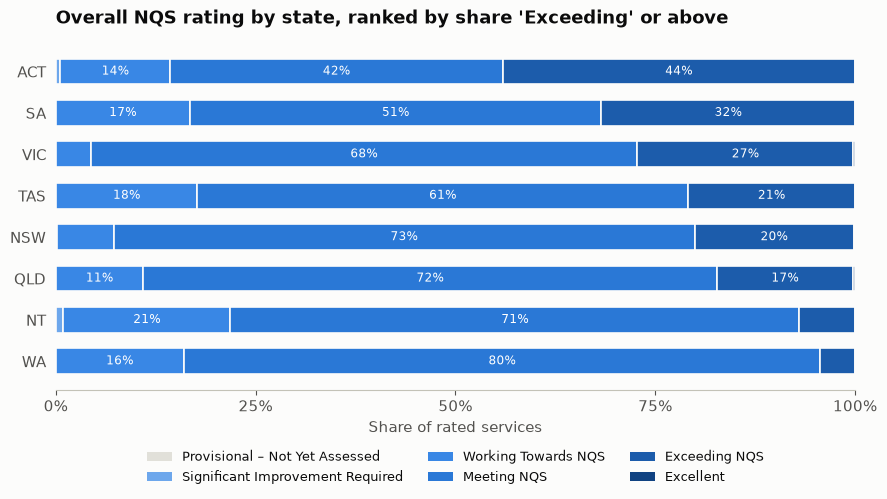

Best: ACT (44.1% Exceeding+)   Worst: WA (4.3% Exceeding+)


In [9]:

rated = df[df["State"].notna()].copy()
rated["OverallRating"] = rated["OverallRating"].astype(str)
props = (
    rated.groupby("State")["OverallRating"].value_counts(normalize=True)
    .unstack(fill_value=0).reindex(columns=RATING_ORDER, fill_value=0)
)
props["_score"] = props["Exceeding NQS"] + props["Excellent"]
props = props.sort_values("_score", ascending=False).drop(columns="_score")

fig, ax = plt.subplots(figsize=(9, 5.2))
stacked_bar(ax, props, RATING_ORDER, RATING_COLORS)
ax.set_title("Overall NQS rating by state, ranked by share 'Exceeding' or above",
             fontsize=13, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.set_xlabel("Share of rated services")
handles = [Patch(facecolor=RATING_COLORS[c], label=c) for c in RATING_ORDER]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_rating_by_state.png", dpi=200)
plt.show()

best_state, worst_state = props.index[0], props.index[-1]
summary["best_state"] = best_state
summary["worst_state"] = worst_state
summary["best_state_exceeding_pct"] = round(float(props.loc[best_state, "Exceeding NQS"] + props.loc[best_state, "Excellent"]) * 100, 1)
summary["worst_state_exceeding_pct"] = round(float(props.loc[worst_state, "Exceeding NQS"] + props.loc[worst_state, "Excellent"]) * 100, 1)
print(f"Best: {best_state} ({summary['best_state_exceeding_pct']}% Exceeding+)   Worst: {worst_state} ({summary['worst_state_exceeding_pct']}% Exceeding+)")



## 5. Chart 2 — NQS rating by primary service type


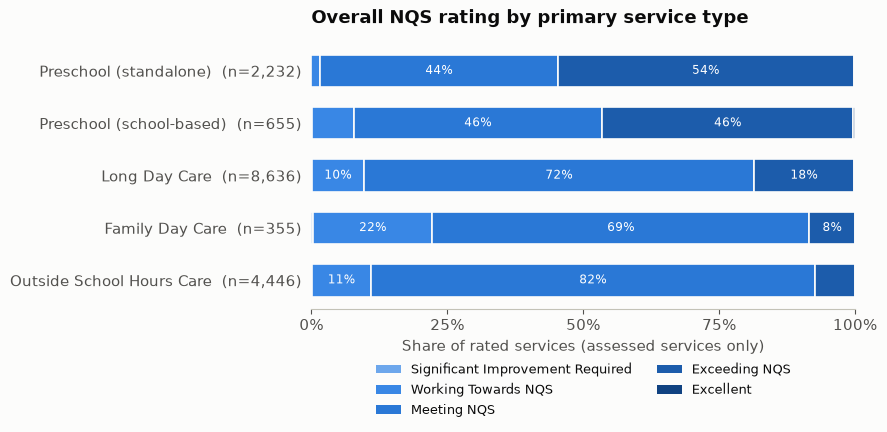

In [10]:

d2 = df[df["PrimaryServiceType"] != "Other"].copy()
d2 = d2[d2["OverallRating"].notna()]
d2["OverallRating"] = d2["OverallRating"].astype(str)
d2 = d2[d2["OverallRating"] != NOT_YET_ASSESSED]

props2 = (
    d2.groupby("PrimaryServiceType")["OverallRating"].value_counts(normalize=True)
    .unstack(fill_value=0).reindex(columns=RATING_ORDER_SUBSTANTIVE, fill_value=0)
)
counts2 = d2["PrimaryServiceType"].value_counts()
props2["_score"] = props2["Exceeding NQS"] + props2["Excellent"]
props2 = props2.sort_values("_score", ascending=False).drop(columns="_score")
props2.index = [f"{i}  (n={counts2[i]:,})" for i in props2.index]

fig, ax = plt.subplots(figsize=(9, 4.6))
stacked_bar(ax, props2, RATING_ORDER_SUBSTANTIVE, RATING_COLORS)
ax.set_title("Overall NQS rating by primary service type", fontsize=13, fontweight="bold",
             color=INK_PRIMARY, loc="left", pad=14)
ax.set_xlabel("Share of rated services (assessed services only)")
handles = [Patch(facecolor=RATING_COLORS[c], label=c) for c in RATING_ORDER_SUBSTANTIVE]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_rating_by_service_type.png", dpi=200)
plt.show()

summary["service_type_counts"] = counts2.to_dict()



## 6. Chart 3 — Which Quality Area drags each state down?

**Business question:** a low overall rating is made of seven component scores — which one should each state's regulator prioritise?


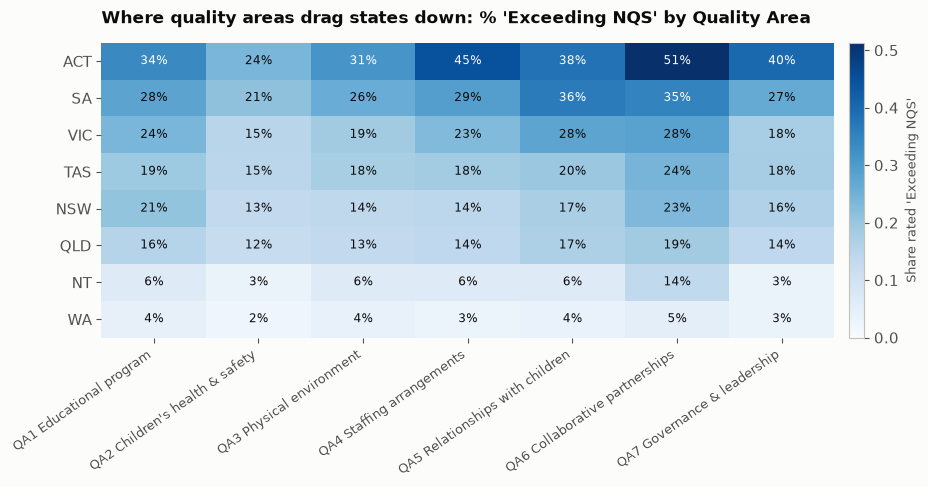

Weakest: QA2 Children's health & safety  Strongest: QA6 Collaborative partnerships


In [11]:

d3 = df[df["State"].notna()].copy()
qa_cols = list(QUALITY_AREA_LABELS.keys())
rows = []
for state, g in d3.groupby("State"):
    row = {}
    for col in qa_cols:
        s = g[col].astype(str)
        s = s[(s != "nan") & (s != NOT_YET_ASSESSED)]
        row[QUALITY_AREA_LABELS[col]] = (s == "Exceeding NQS").mean() if len(s) else np.nan
    rows.append(pd.Series(row, name=state))
heat = pd.DataFrame(rows)
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9.5, 5))
im = ax.imshow(heat.values, cmap="Blues", vmin=0, vmax=heat.values.max(), aspect="auto")
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8.5,
                color="white" if v > heat.values.max() * 0.6 else INK_PRIMARY)
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Share rated 'Exceeding NQS'", color=INK_SECONDARY, fontsize=9)
ax.set_title("Where quality areas drag states down: % 'Exceeding NQS' by Quality Area",
             fontsize=12.5, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_quality_area_heatmap.png", dpi=200)
plt.show()

summary["weakest_quality_area_nationally"] = heat.mean(axis=0).idxmin()
summary["strongest_quality_area_nationally"] = heat.mean(axis=0).idxmax()
print("Weakest:", summary["weakest_quality_area_nationally"], " Strongest:", summary["strongest_quality_area_nationally"])



## 7. Chart 4 (spatial) — Services across Australia by rating

Basemap: simplified Australian state boundaries from [rowanhogan/australian-states](https://github.com/rowanhogan/australian-states) (public GitHub repo derived from ABS boundaries) — visual context only, not a statistical join.


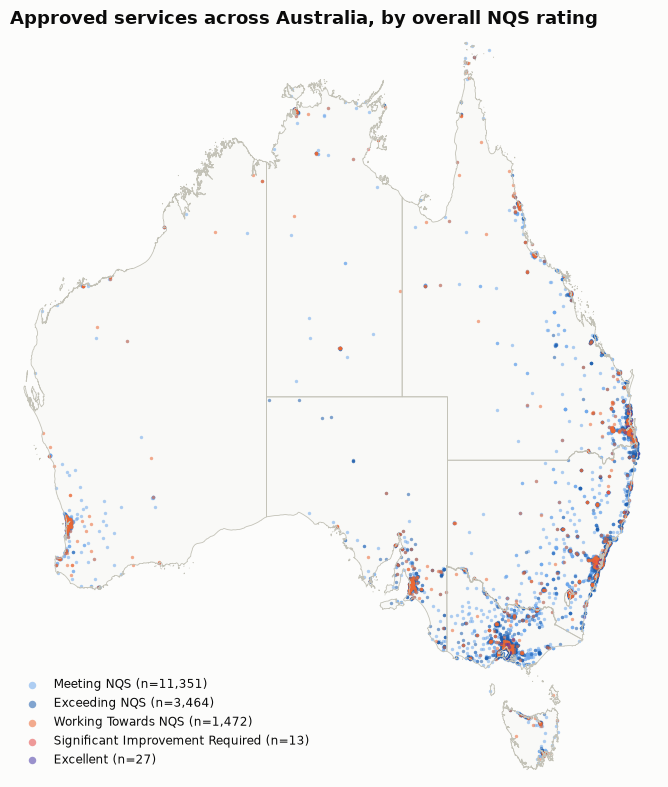

In [12]:

d4 = df[df["lon"].notna() & df["lat"].notna() & ~df["geocode_suspect"]].copy()
d4["OverallRating"] = d4["OverallRating"].astype(str)
tier_colors = {
    "Significant Improvement Required": CAT["red"], "Working Towards NQS": CAT["orange"],
    "Meeting NQS": SEQ_BLUE[2], "Exceeding NQS": SEQ_BLUE[5], "Excellent": CAT["violet"],
}
states = gpd.read_file(AU_STATES_GEOJSON)

fig, ax = plt.subplots(figsize=(9, 8))
states.boundary.plot(ax=ax, color=BASELINE, linewidth=0.6)
states.plot(ax=ax, color="#f9f9f7", edgecolor="none", zorder=0)
for tier in ["Meeting NQS", "Exceeding NQS", "Working Towards NQS", "Significant Improvement Required", "Excellent"]:
    sub = d4[d4["OverallRating"] == tier]
    if len(sub) == 0:
        continue
    ax.scatter(sub["lon"], sub["lat"], s=6, alpha=0.55, linewidths=0, color=tier_colors[tier], label=f"{tier} (n={len(sub):,})")
ax.set_xlim(112, 155); ax.set_ylim(-44, -9); ax.set_aspect(1.4)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Approved services across Australia, by overall NQS rating", fontsize=13, fontweight="bold", color=INK_PRIMARY, loc="left", pad=10)
ax.legend(loc="lower left", frameon=False, fontsize=8.5, markerscale=2.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_spatial_ratings_map.png", dpi=200)
plt.show()

summary["n_mapped"] = int(len(d4))
summary["n_excluded_suspect_geocode"] = int(df["geocode_suspect"].sum())



## 8. Chart 5 — Does distance from transport hurt quality?

**Business question:** does poor transport access have a NEGATIVE impact on quality — i.e. does it push services below the NQS standard, not just below "Exceeding"? Torres Strait Island / very remote services (>100km from a station — genuine, not a data error) are excluded here only, since at national scale they'd compress every other distance bin onto a single pixel.


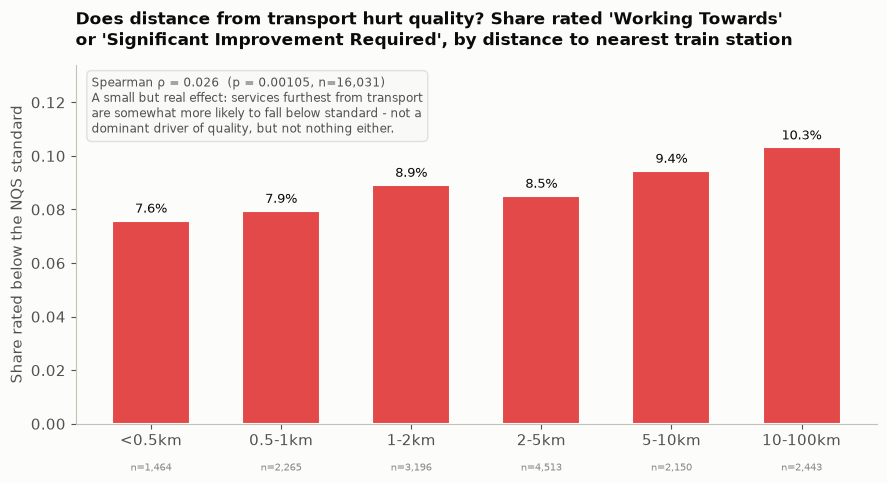

Spearman rho = 0.0259, p = 0.00105, n = 16,031


In [13]:

idx5 = rated_only(df["OverallRating"].dropna()).index
sub5 = df.loc[idx5].copy()
sub5["OverallRating"] = sub5["OverallRating"].astype(str)
# "Negative impact" = falling BELOW the NQS standard (Working Towards NQS or
# Significant Improvement Required) - a direct "at risk" measure, rather than
# the share exceeding it.
sub5["BelowStandard"] = sub5["OverallRating"].isin(["Working Towards NQS", "Significant Improvement Required"]).astype(int)
sub5_clean = sub5[~sub5["train_dist_outlier"]].copy()
n_excluded5 = int(sub5["train_dist_outlier"].sum())

bins5 = [0, 0.5, 1, 2, 5, 10, 100]
labels5 = ["<0.5km", "0.5-1km", "1-2km", "2-5km", "5-10km", "10-100km"]
sub5_clean["dist_bin"] = pd.cut(sub5_clean["DistanceToTrainStation_km"], bins=bins5, labels=labels5)
props5 = sub5_clean.groupby("dist_bin", observed=True)["BelowStandard"].mean()
counts5 = sub5_clean["dist_bin"].value_counts().reindex(labels5)

rho5, pval5 = stats.spearmanr(sub5_clean["DistanceToTrainStation_km"], sub5_clean["BelowStandard"])

ymax5 = max(props5.max() * 1.3, 0.05)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels5, props5.reindex(labels5).values, color=CAT["red"], width=0.6, edgecolor=SURFACE, linewidth=1.5)
for bar, lbl in zip(bars, labels5):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003, f"{bar.get_height():.1%}", ha="center", fontsize=9, color=INK_PRIMARY)
    ax.text(bar.get_x() + bar.get_width() / 2, -0.13 * ymax5, f"n={counts5[lbl]:,}", ha="center", fontsize=7.5, color=INK_MUTED)
ax.set_ylim(0, ymax5)
ax.set_ylabel("Share rated below the NQS standard")
ax.set_title("Does distance from transport hurt quality? Share rated 'Working Towards'\nor 'Significant Improvement Required', by distance to nearest train station",
             fontsize=12.5, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.text(0.02, 0.97, f"Spearman ρ = {rho5:.3f}  (p = {pval5:.3g}, n={len(sub5_clean):,})\n"
                    "A small but real effect: services furthest from transport\n"
                    "are somewhat more likely to fall below standard - not a\n"
                    "dominant driver of quality, but not nothing either.",
        transform=ax.transAxes, ha="left", va="top", fontsize=8.5, color=INK_SECONDARY,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f7", edgecolor=GRIDLINE))
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_transport_vs_quality.png", dpi=200)
plt.show()

summary["transport_belowstandard_spearman_rho"] = round(float(rho5), 4)
summary["transport_belowstandard_spearman_p"] = float(pval5)
summary["belowstandard_pct_closest_bin"] = round(float(props5.iloc[0]) * 100, 1)
summary["belowstandard_pct_farthest_bin"] = round(float(props5.iloc[-1]) * 100, 1)
summary["n_excluded_remote_outliers"] = n_excluded5
print(f"Spearman rho = {rho5:.4f}, p = {pval5:.3g}, n = {len(sub5_clean):,}")



# Stream 2: Accessibility & Coverage

## 9. Urban/rural classification — ABS Section of State (SOS) 2021

Per the assignment brief, Option A (spatial join) is used: each service's own lon/lat is matched against the ABS **Section of State** boundary polygons via `geopandas.sjoin`. SOS was chosen over the coarser Remoteness Areas file because its population-based categories (Major Urban / Other Urban / Bounded Locality / Rural Balance) collapse naturally into an urban/rural binary.

Source: ABS Digital Boundary Files, `SOS_2021_AUST_GDA2020` shapefile (included in this repo under `data/external/sos_2021/`).

A handful of coastal/island points fall just outside every polygon due to coastline generalisation — those get a nearest-polygon fallback rather than being left unclassified (only 1 of 17,653 services needed it).


In [14]:

URBAN_CATEGORIES = {"Major Urban", "Other Urban"}
RURAL_CATEGORIES = {"Bounded Locality", "Rural Balance"}


def classify_urban_rural(df):
    sos = gpd.read_file(SOS_SHAPEFILE)
    sos = sos[sos.geometry.notna()].copy()

    pts = gpd.GeoDataFrame(
        df[["lon", "lat"]], geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326", index=df.index,
    ).to_crs(sos.crs)

    cols = ["SOS_NAME21", "STE_NAME21", "geometry"]
    joined = gpd.sjoin(pts, sos[cols], how="left", predicate="within")
    joined = joined[~joined.index.duplicated(keep="first")]

    unmatched = joined["SOS_NAME21"].isna()
    if unmatched.any():
        albers = "EPSG:3577"
        nearest = gpd.sjoin_nearest(pts.loc[unmatched].to_crs(albers), sos[cols].to_crs(albers), how="left")
        nearest = nearest[~nearest.index.duplicated(keep="first")]
        joined.loc[unmatched, "SOS_NAME21"] = nearest["SOS_NAME21"]
        joined.loc[unmatched, "STE_NAME21"] = nearest["STE_NAME21"]

    out = df.copy()
    out["SOS_Category"] = joined["SOS_NAME21"].reindex(out.index)
    out["UrbanRural"] = out["SOS_Category"].map(
        lambda c: "Urban" if c in URBAN_CATEGORIES else ("Rural" if c in RURAL_CATEGORIES else pd.NA)
    )
    return out


df = classify_urban_rural(df)
SOS_ORDER = ["Major Urban", "Other Urban", "Bounded Locality", "Rural Balance"]
SOS_COLORS = {"Major Urban": SEQ_BLUE[5], "Other Urban": SEQ_BLUE[3], "Bounded Locality": CAT["orange"], "Rural Balance": CAT["red"]}
summary["urban_rural_counts"] = df["UrbanRural"].value_counts(dropna=False).to_dict()
summary["sos_category_counts"] = df["SOS_Category"].value_counts(dropna=False).to_dict()
df["SOS_Category"].value_counts(dropna=False)


SOS_Category
Major Urban         12850
Other Urban          3578
Bounded Locality      616
Rural Balance         609
Name: count, dtype: int64


## 10. Chart 6 — Transport access, all four Section of State categories

Rather than collapsing to a binary urban/rural split, this uses all four ABS SOS categories directly - the Bounded Locality vs Rural Balance distinction turns out to matter (see below).


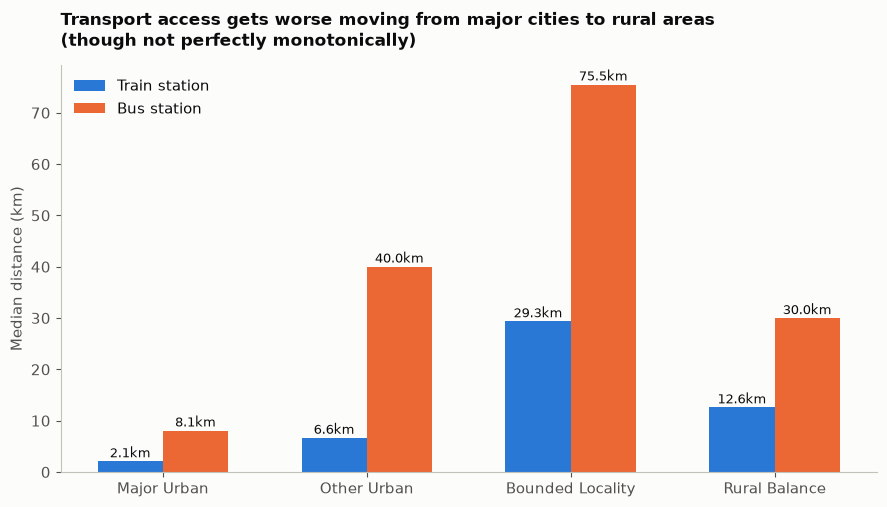

                  DistanceToTrainStation_km  DistanceToBusStation_km
SOS_Category                                                        
Major Urban                        2.071244                 8.070284
Other Urban                        6.644337                40.009442
Bounded Locality                  29.345627                75.489909
Rural Balance                     12.574765                29.961635


In [15]:

d6 = df[df["SOS_Category"].notna()]
medians6 = d6.groupby("SOS_Category")[["DistanceToTrainStation_km", "DistanceToBusStation_km"]].median().reindex(SOS_ORDER)

fig, ax = plt.subplots(figsize=(9, 5.2))
x = np.arange(len(SOS_ORDER)); w = 0.32
ax.bar(x - w / 2, medians6["DistanceToTrainStation_km"], width=w, color=CAT["blue"], label="Train station")
ax.bar(x + w / 2, medians6["DistanceToBusStation_km"], width=w, color=CAT["orange"], label="Bus station")
for i, cat in enumerate(SOS_ORDER):
    ax.text(i - w / 2, medians6.loc[cat, "DistanceToTrainStation_km"] + 0.8, f"{medians6.loc[cat, 'DistanceToTrainStation_km']:.1f}km", ha="center", fontsize=9)
    ax.text(i + w / 2, medians6.loc[cat, "DistanceToBusStation_km"] + 0.8, f"{medians6.loc[cat, 'DistanceToBusStation_km']:.1f}km", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(SOS_ORDER)
ax.set_ylabel("Median distance (km)")
ax.set_title("Transport access gets worse moving from major cities to rural areas\n(though not perfectly monotonically)", fontsize=12.5, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.legend(frameon=False, loc="upper left")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_transport_by_urban_rural.png", dpi=200)
plt.show()

for cat in SOS_ORDER:
    summary[f"{cat.lower().replace(' ', '_')}_median_train_km"] = round(float(medians6.loc[cat, "DistanceToTrainStation_km"]), 2)
print(medians6)



## 11. Chart 7 — Does the Section of State split show up in quality?


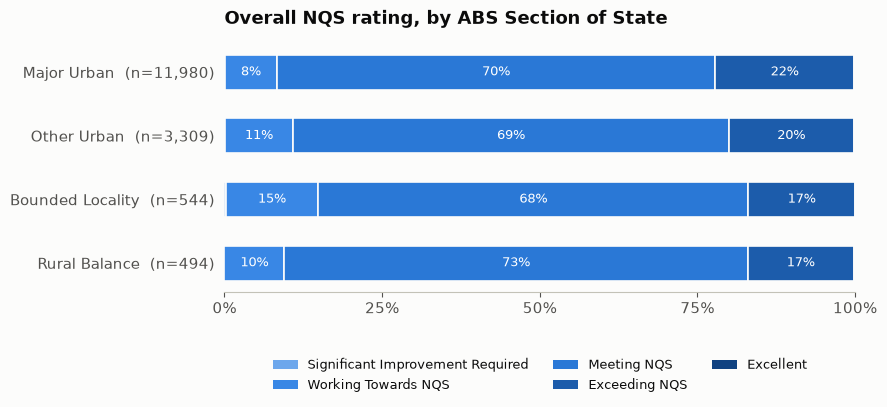

Major Urban  (n=11,980)      0.221452
Other Urban  (n=3,309)       0.200060
Bounded Locality  (n=544)    0.169118
Rural Balance  (n=494)       0.170040
dtype: float64


In [16]:

d7 = df[df["SOS_Category"].notna() & df["OverallRating"].notna()].copy()
d7["OverallRating"] = d7["OverallRating"].astype(str)
d7 = d7[d7["OverallRating"] != NOT_YET_ASSESSED]
props7 = (
    d7.groupby("SOS_Category")["OverallRating"].value_counts(normalize=True)
    .unstack(fill_value=0).reindex(columns=RATING_ORDER_SUBSTANTIVE, fill_value=0).reindex(SOS_ORDER)
)
counts7 = d7["SOS_Category"].value_counts()
props7.index = [f"{i}  (n={counts7[i]:,})" for i in props7.index]

fig, ax = plt.subplots(figsize=(9, 4.4))
left = np.zeros(len(props7)); y = np.arange(len(props7))
for cat in RATING_ORDER_SUBSTANTIVE:
    vals = props7[cat].to_numpy()
    ax.barh(y, vals, left=left, height=0.55, color=RATING_COLORS[cat], edgecolor=SURFACE, linewidth=1.2, label=cat)
    for i, v in enumerate(vals):
        if v >= 0.06:
            ax.text(left[i] + v / 2, y[i], f"{v:.0%}", ha="center", va="center", fontsize=9, color="white")
    left += vals
ax.set_yticks(y); ax.set_yticklabels(props7.index)
ax.set_xlim(0, 1); ax.set_xticks([0, .25, .5, .75, 1.0]); ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.invert_yaxis()
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.set_title("Overall NQS rating, by ABS Section of State", fontsize=13, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
handles = [Patch(facecolor=RATING_COLORS[c], label=c) for c in RATING_ORDER_SUBSTANTIVE]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_rating_by_urban_rural.png", dpi=200)
plt.show()

exceeding_by_cat = props7[["Exceeding NQS", "Excellent"]].sum(axis=1)
for cat, label in zip(SOS_ORDER, exceeding_by_cat.index):
    summary[f"{cat.lower().replace(' ', '_')}_exceeding_pct"] = round(float(exceeding_by_cat[label]) * 100, 1)
print(exceeding_by_cat)



## 12. Chart 8 (spatial) — Urban centres vs rural areas across Australia


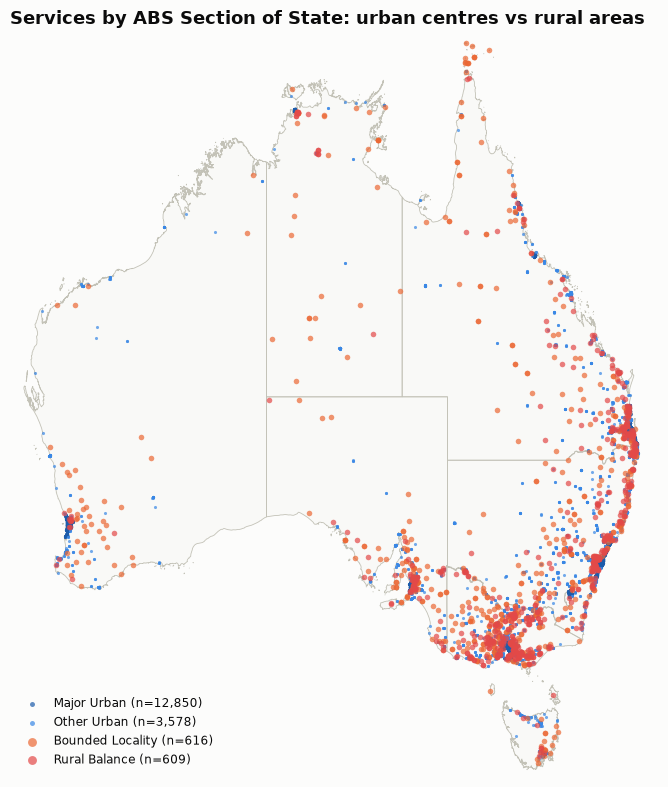

In [17]:

d8 = df[df["lon"].notna() & df["lat"].notna() & ~df["geocode_suspect"] & df["SOS_Category"].notna()]
states = gpd.read_file(AU_STATES_GEOJSON)

fig, ax = plt.subplots(figsize=(9, 8))
states.boundary.plot(ax=ax, color=BASELINE, linewidth=0.6)
states.plot(ax=ax, color="#f9f9f7", edgecolor="none", zorder=0)
for cat in SOS_ORDER:
    sub = d8[d8["SOS_Category"] == cat]
    if len(sub) == 0:
        continue
    s = 5 if cat in ("Major Urban", "Other Urban") else 16
    ax.scatter(sub["lon"], sub["lat"], s=s, alpha=0.7, linewidths=0, color=SOS_COLORS[cat], label=f"{cat} (n={len(sub):,})", zorder=3 if s > 5 else 2)
ax.set_xlim(112, 155); ax.set_ylim(-44, -9); ax.set_aspect(1.4)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Services by ABS Section of State: urban centres vs rural areas", fontsize=13, fontweight="bold", color=INK_PRIMARY, loc="left", pad=10)
ax.legend(loc="lower left", frameon=False, fontsize=8.5, markerscale=1.6)
fig.tight_layout()
fig.savefig(FIG_DIR / "08_spatial_urban_rural.png", dpi=200)
plt.show()



## 13. Chart 9 — Coverage gaps: where is the next service furthest away?

**Business question:** land-area service density is dominated by uninhabited land in a country this size, so it's not a useful "underserved" signal on its own. A more direct coverage measure: for each service, how far is the *nearest other service* — i.e. the nearest fallback if a family's usual service is full or closes.


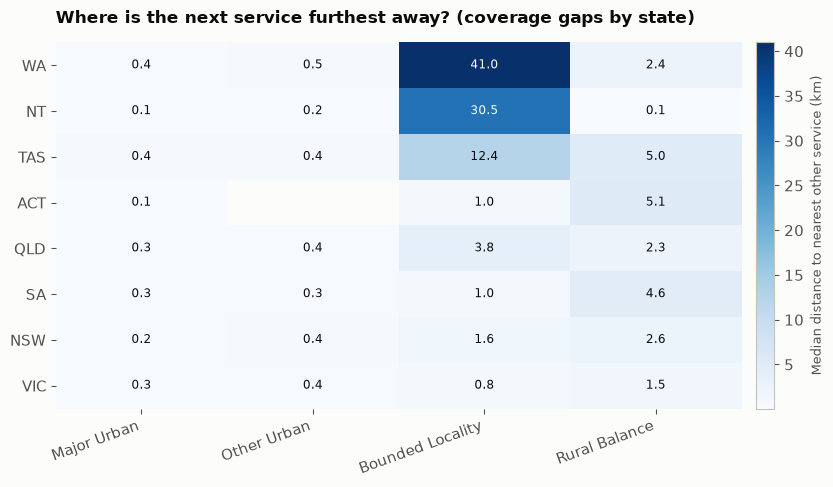

Most underserved: WA / Bounded Locality — median 41.0km to the nearest other service


In [18]:

pts9 = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326").to_crs("EPSG:3577")
coords9 = np.vstack([pts9.geometry.x, pts9.geometry.y]).T
dist9, _ = cKDTree(coords9).query(coords9, k=2)
df["nearest_service_km"] = dist9[:, 1] / 1000

d9 = df[df["State"].notna() & df["SOS_Category"].notna()]
grid9 = d9.groupby(["State", "SOS_Category"])["nearest_service_km"].median().unstack().reindex(columns=SOS_ORDER)
grid9 = grid9.loc[grid9.mean(axis=1, skipna=True).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8.5, 5))
vals9 = grid9.values.astype(float)
im = ax.imshow(np.ma.masked_invalid(vals9), cmap="Blues", aspect="auto")
ax.set_xticks(range(len(grid9.columns))); ax.set_xticklabels(grid9.columns, rotation=20, ha="right")
ax.set_yticks(range(len(grid9.index))); ax.set_yticklabels(grid9.index)
for i in range(vals9.shape[0]):
    for j in range(vals9.shape[1]):
        v = vals9[i, j]
        if np.isnan(v):
            continue
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8.5, color="white" if v > np.nanmax(vals9) * 0.55 else INK_PRIMARY)
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Median distance to nearest other service (km)", color=INK_SECONDARY, fontsize=9)
ax.set_title("Where is the next service furthest away? (coverage gaps by state)", fontsize=12, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "09_coverage_gaps.png", dpi=200)
plt.show()

flat9 = grid9.stack()
worst_gap = flat9.idxmax()
summary["most_underserved_state_sos"] = f"{worst_gap[0]} / {worst_gap[1]}"
summary["most_underserved_median_km"] = round(float(flat9.max()), 1)
print(f"Most underserved: {summary['most_underserved_state_sos']} — median {summary['most_underserved_median_km']}km to the nearest other service")



# Stream 3: Operational Trends

## 14. Capacity, operating hours & approval dates

Setting up two operational fields: capacity is already in the data (`NumberOfApprovedPlaces`); opening hours need to be derived from the per-weekday start/end time columns. Services record hours under three separate schedules — "Annual" (year-round), "School Terms Only" (two sessions), and "Holiday Care" — so which one a service has filled in is itself informative about how it operates.


In [19]:

DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

has_annual = df["Annual Monday Start Time"].notna()
has_term = df["School Terms Only Session 1 Monday Start Time"].notna()
df["OperatingPattern"] = "Neither / other pattern"
df.loc[~has_annual & has_term, "OperatingPattern"] = "Term-time only"
df.loc[has_annual, "OperatingPattern"] = "Year-round"


def to_hours(series):
    return pd.to_timedelta(series.astype(str), errors="coerce").dt.total_seconds() / 3600


total_hours = pd.Series(0.0, index=df.index)
for day in DAYS:
    start = to_hours(df[f"Annual {day} Start Time"])
    end = to_hours(df[f"Annual {day} End Time"])
    total_hours = total_hours.add((end - start).clip(lower=0).fillna(0))
df["WeeklyHours"] = np.where(has_annual, total_hours, np.nan)

# Family Day Care schemes record round-the-clock availability across their
# whole educator network (median ~168h/week = "always open"), which isn't
# a comparable "opening hours" figure to a single centre's - excluded from
# the hours analysis, kept for the capacity/type charts.
df.loc[df["PrimaryServiceType"] == "Family Day Care", "WeeklyHours"] = np.nan

print(df["OperatingPattern"].value_counts())
print()
print(df["WeeklyHours"].describe())


OperatingPattern
Year-round                 10633
Term-time only              6093
Neither / other pattern      927
Name: count, dtype: int64

count    10267.000000
mean        53.731492
std          9.976385
min          0.000000
25%         52.500000
50%         55.000000
75%         60.000000
max        167.883333
Name: WeeklyHours, dtype: float64



## 15. Chart 10 — How big is a typical service, by type?


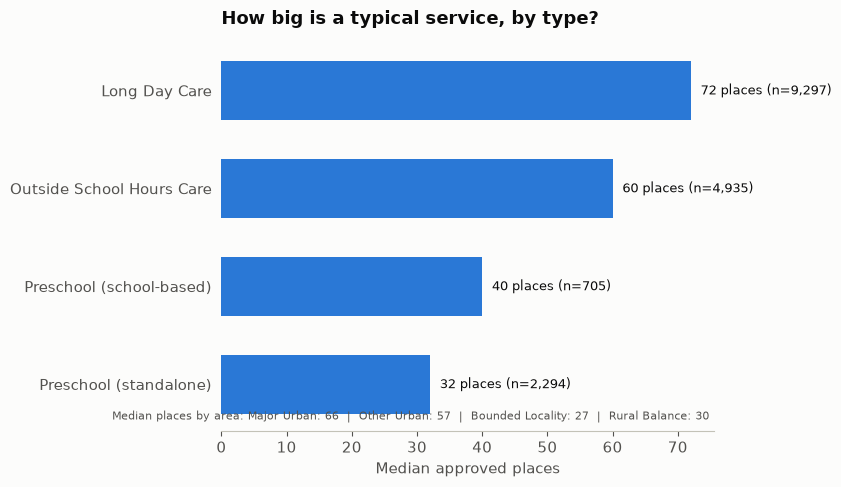

In [20]:

# Family Day Care excluded: capacity is recorded per individually-registered
# educator across a scheme, not as a single site limit, so NumberOfApprovedPlaces
# is populated for only 2 of 417 FDC services - not enough for a meaningful median.
d10 = df[~df["PrimaryServiceType"].isin(["Other", "Family Day Care"])].dropna(subset=["NumberOfApprovedPlaces"])
med10 = d10.groupby("PrimaryServiceType")["NumberOfApprovedPlaces"].median().sort_values(ascending=False)
counts10 = d10["PrimaryServiceType"].value_counts()
sos_places = df.groupby("SOS_Category")["NumberOfApprovedPlaces"].median()

fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.barh(med10.index, med10.values, color=CAT["blue"], height=0.6)
for bar, name in zip(bars, med10.index):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2, f"{bar.get_width():.0f} places (n={counts10[name]:,})", va="center", fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Median approved places")
ax.set_title("How big is a typical service, by type?", fontsize=13, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
sos_line = "  |  ".join(f"{cat}: {sos_places[cat]:.0f}" for cat in SOS_ORDER)
ax.text(0.99, 0.03, f"Median places by area: {sos_line}",
        transform=ax.transAxes, ha="right", fontsize=8, color=INK_SECONDARY)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_capacity_by_type.png", dpi=200)
plt.show()

for cat in SOS_ORDER:
    summary[f"median_places_{cat.lower().replace(' ', '_')}"] = round(float(sos_places[cat]), 1)



## 16. Chart 11 — Year-round vs term-time-only operation, by service type


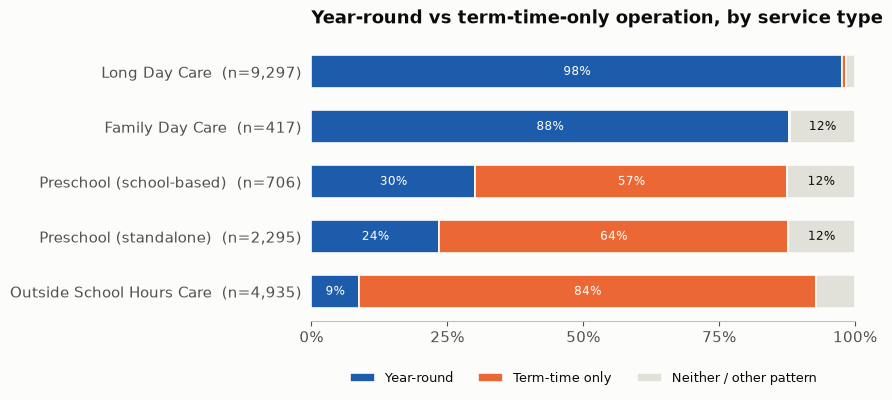

In [21]:

d11 = df[df["PrimaryServiceType"] != "Other"]
ct11 = pd.crosstab(d11["PrimaryServiceType"], d11["OperatingPattern"], normalize="index")
order11 = ["Year-round", "Term-time only", "Neither / other pattern"]
ct11 = ct11.reindex(columns=order11, fill_value=0).sort_values("Year-round", ascending=False)
counts11 = d11["PrimaryServiceType"].value_counts()
ct11.index = [f"{i}  (n={counts11[i]:,})" for i in ct11.index]

colors11 = {"Year-round": SEQ_BLUE[5], "Term-time only": CAT["orange"], "Neither / other pattern": GRIDLINE}
fig, ax = plt.subplots(figsize=(9, 4.2))
left = np.zeros(len(ct11)); y = np.arange(len(ct11))
for cat in order11:
    vals = ct11[cat].to_numpy()
    ax.barh(y, vals, left=left, height=0.6, color=colors11[cat], edgecolor=SURFACE, linewidth=1.2, label=cat)
    for i, v in enumerate(vals):
        if v >= 0.08:
            ax.text(left[i] + v / 2, y[i], f"{v:.0%}", ha="center", va="center", fontsize=8.5, color="white" if cat != "Neither / other pattern" else INK_PRIMARY)
    left += vals
ax.set_yticks(y); ax.set_yticklabels(ct11.index)
ax.set_xlim(0, 1); ax.set_xticks([0, .25, .5, .75, 1.0]); ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.invert_yaxis()
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.set_title("Year-round vs term-time-only operation, by service type", fontsize=13, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "11_operating_pattern_by_type.png", dpi=200)
plt.show()



## 17. Chart 12 — Services approved per year

**Data quality note:** 2012 shows an enormous spike. That's not organic growth — the National Quality Framework commenced in January 2012, and every already-operating service was bulk-transferred onto new approval numbers under the new system that year. Read the post-2013 trend as the real growth signal.


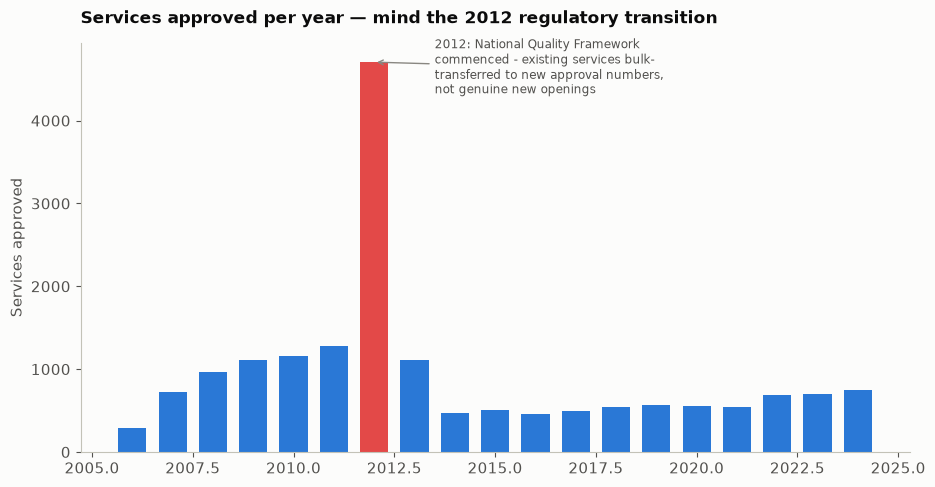

In [22]:

d12 = df[df["ApprovalYear"].between(2006, 2024)]
by_year = d12.groupby("ApprovalYear").size()

fig, ax = plt.subplots(figsize=(9.5, 5))
colors12 = [CAT["red"] if y == 2012 else CAT["blue"] for y in by_year.index]
ax.bar(by_year.index, by_year.values, color=colors12, width=0.7)
ax.annotate(
    "2012: National Quality Framework\ncommenced - existing services bulk-\ntransferred to new approval numbers,\nnot genuine new openings",
    xy=(2012, by_year.loc[2012]), xytext=(2013.5, by_year.loc[2012] * 0.92),
    fontsize=8.5, color=INK_SECONDARY, arrowprops=dict(arrowstyle="->", color=INK_MUTED),
)
ax.set_ylabel("Services approved")
ax.set_title("Services approved per year — mind the 2012 regulatory transition", fontsize=12.5, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "12_approval_trend.png", dpi=200)
plt.show()

summary["approvals_2012_nqf_spike"] = int(by_year.loc[2012])
summary["approvals_2014"] = int(by_year.loc[2014])
summary["approvals_2024"] = int(by_year.loc[2024])



## 18. Chart 13 — Do operational factors relate to quality, and does transport?

Two questions in one chart: does a longer working week associate with quality, and — following up on Chart 5's finding that distance from transport has a small but real negative effect on quality — does transport accessibility move capacity or opening hours at all?


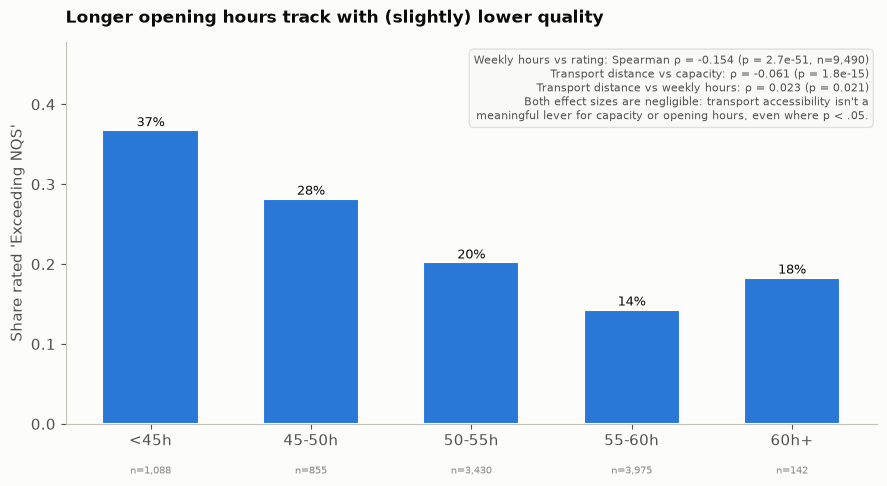

In [23]:

d13 = df[df["OverallRating"].notna() & df["WeeklyHours"].notna()].copy()
d13["OverallRating"] = d13["OverallRating"].astype(str)
d13 = d13[d13["OverallRating"] != NOT_YET_ASSESSED]
d13 = d13[d13["WeeklyHours"].between(1, 100)]
d13["rating_code"] = d13["OverallRating"].map({v: i for i, v in enumerate(RATING_ORDER_SUBSTANTIVE)})

bins13 = [0, 45, 50, 55, 60, 100]
labels13 = ["<45h", "45-50h", "50-55h", "55-60h", "60h+"]
d13["hours_bin"] = pd.cut(d13["WeeklyHours"], bins=bins13, labels=labels13)
props13 = d13.groupby("hours_bin", observed=True)["OverallRating"].apply(lambda s: (s == "Exceeding NQS").mean())
counts13 = d13["hours_bin"].value_counts().reindex(labels13)

rho_hours, p_hours = stats.spearmanr(d13["WeeklyHours"], d13["rating_code"])

cap13 = df.dropna(subset=["NumberOfApprovedPlaces"])
cap13 = cap13[~cap13["train_dist_outlier"]]
rho_cap, p_cap = stats.spearmanr(cap13["DistanceToTrainStation_km"], cap13["NumberOfApprovedPlaces"])

hrs13 = df.dropna(subset=["WeeklyHours"])
hrs13 = hrs13[~hrs13["train_dist_outlier"] & hrs13["WeeklyHours"].between(1, 100)]
rho_transport_hours, p_transport_hours = stats.spearmanr(hrs13["DistanceToTrainStation_km"], hrs13["WeeklyHours"])

ymax13 = max(props13.max() * 1.3, 0.05)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels13, props13.reindex(labels13).values, color=CAT["blue"], width=0.6, edgecolor=SURFACE, linewidth=1.5)
for bar, lbl in zip(bars, labels13):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{bar.get_height():.0%}", ha="center", fontsize=9, color=INK_PRIMARY)
    ax.text(bar.get_x() + bar.get_width() / 2, -0.13 * ymax13, f"n={counts13[lbl]:,}", ha="center", fontsize=7.5, color=INK_MUTED)
ax.set_ylim(0, ymax13)
ax.set_ylabel("Share rated 'Exceeding NQS'")
ax.set_title("Longer opening hours track with (slightly) lower quality", fontsize=12.5, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.text(0.99, 0.97,
        f"Weekly hours vs rating: Spearman ρ = {rho_hours:.3f} (p = {p_hours:.2g}, n={len(d13):,})\n"
        f"Transport distance vs capacity: ρ = {rho_cap:.3f} (p = {p_cap:.2g})\n"
        f"Transport distance vs weekly hours: ρ = {rho_transport_hours:.3f} (p = {p_transport_hours:.2g})\n"
        "Both effect sizes are negligible: transport accessibility isn't a\n"
        "meaningful lever for capacity or opening hours, even where p < .05.",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color=INK_SECONDARY,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f7", edgecolor=GRIDLINE))
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "13_hours_vs_quality.png", dpi=200)
plt.show()

summary["hours_quality_spearman_rho"] = round(float(rho_hours), 4)
summary["hours_quality_spearman_p"] = float(p_hours)
summary["transport_capacity_spearman_rho"] = round(float(rho_cap), 4)
summary["transport_hours_spearman_rho"] = round(float(rho_transport_hours), 4)
summary["transport_hours_spearman_p"] = float(p_transport_hours)



## 19. Summary for the presentation

**Service Quality**
- **State spread is large**: ACT has the highest share of services rated "Exceeding NQS" or above, WA the lowest — a wide gap between regulatory jurisdictions applying the same National Law.
- **QA2 (Children's health & safety)** is the weakest Quality Area nationally; **QA6 (Collaborative partnerships)** the strongest.
- **Distance from transport has a small but real negative effect on quality**: services furthest from a train station are somewhat more likely to fall below the NQS standard (10.3% vs 7.6% for the closest, Spearman ρ ≈ 0.026) — a modest risk factor, not a dominant one.

**Accessibility & Coverage**
- **Transport access worsens moving from major cities to rural areas, but not monotonically**: Bounded Localities (small country towns) are actually furthest from a train station (29.3km median) - further than the more sparsely-populated Rural Balance category (12.6km) - while Major Urban sits at 2.1km.
- **Quality declines steadily across the four categories**: 22.1% Exceeding+ in Major Urban, down to 16.9-17.0% in Bounded Locality and Rural Balance.
- **WA's and NT's Bounded Localities are the standout coverage gaps**: median 41.0km and 30.5km to the nearest other service.

**Operational Trends**
- **Capacity declines from Major Urban (66 places median) to Bounded Locality (27) and Rural Balance (30)** — smaller communities, smaller centres.
- **Long Day Care and Family Day Care run year-round**; **Preschools and Outside School Hours Care are overwhelmingly term-time only** — a structural split in how the sector operates, not a quality difference.
- **2012 is a regulatory artifact, not a growth spike**: the National Quality Framework's launch bulk-transferred every existing service onto new approval numbers that year. The real post-transition trend (2013 onward) is a much steadier signal.
- **Longer opening hours track with modestly lower quality** (ρ ≈ -0.15) — the largest operational-factor effect found, larger than transport's. **Transport accessibility does not meaningfully move either capacity or opening hours** (both effect sizes negligible, even where technically significant) — so while Chart 5 shows transport has a small negative effect on quality directly, that effect isn't operating *through* capacity or hours; it's a standalone, modest risk factor.

**Data quality**
- 10 rows were dropped as unrecoverable geocoding failures (no address data at all); everything else was checked and kept.
- Family Day Care schemes were excluded from the opening-hours analysis: they record round-the-clock availability across their educator network, not comparable to a single centre's hours.


In [24]:

Path("outputs").mkdir(exist_ok=True)
Path("outputs/summary_stats.json").write_text(json.dumps(summary, indent=2, default=str))
summary


{'n_services_total': 17653,
 'best_state': 'ACT',
 'worst_state': 'WA',
 'best_state_exceeding_pct': 44.1,
 'worst_state_exceeding_pct': 4.3,
 'service_type_counts': {'Long Day Care': 8636,
  'Outside School Hours Care': 4446,
  'Preschool (standalone)': 2232,
  'Preschool (school-based)': 655,
  'Family Day Care': 355},
 'weakest_quality_area_nationally': "QA2 Children's health & safety",
 'strongest_quality_area_nationally': 'QA6 Collaborative partnerships',
 'n_mapped': 17653,
 'n_excluded_suspect_geocode': 0,
 'transport_belowstandard_spearman_rho': 0.0259,
 'transport_belowstandard_spearman_p': 0.0010535622964976603,
 'belowstandard_pct_closest_bin': 7.6,
 'belowstandard_pct_farthest_bin': 10.3,
 'n_excluded_remote_outliers': 296,
 'urban_rural_counts': {'Urban': 16428, 'Rural': 1225},
 'sos_category_counts': {'Major Urban': 12850,
  'Other Urban': 3578,
  'Bounded Locality': 616,
  'Rural Balance': 609},
 'major_urban_median_train_km': 2.07,
 'other_urban_median_train_km': 6.64,
